In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

In [ ]:
# Load the dataset
data = pd.read_csv("sales_data.csv")

In [ ]:
# Display the first five records
print("First Five Records:")
print(data.head())

First Five Records:
   Unnamed: 0  TV Ad Budget ($)  Radio Ad Budget ($)  Newspaper Ad Budget ($)  \
0           1             230.1                 37.8                     69.2   
1           2              44.5                 39.3                     45.1   
2           3              17.2                 45.9                     69.3   
3           4             151.5                 41.3                     58.5   
4           5             180.8                 10.8                     58.4   

   Sales ($)  
0       22.1  
1       10.4  
2        9.3  
3       18.5  
4       12.9  


In [7]:
#Identify independent and dependent variables
print("Independent Variable: TV Ad Budget ($)")
print("Dependent Variable: Sales ($)")

Independent Variable: TV Ad Budget ($)
Dependent Variable: Sales ($)


In [8]:
#Select independent and dependent variables
X = data[["TV Ad Budget ($)"]]
y = data["Sales ($)"]

print(X.head())
print(y.head())

   TV Ad Budget ($)
0             230.1
1              44.5
2              17.2
3             151.5
4             180.8
0    22.1
1    10.4
2     9.3
3    18.5
4    12.9
Name: Sales ($), dtype: float64


In [9]:
#check missing values
print(data.isnull().sum())

Unnamed: 0                 0
TV Ad Budget ($)           0
Radio Ad Budget ($)        0
Newspaper Ad Budget ($)    0
Sales ($)                  0
dtype: int64


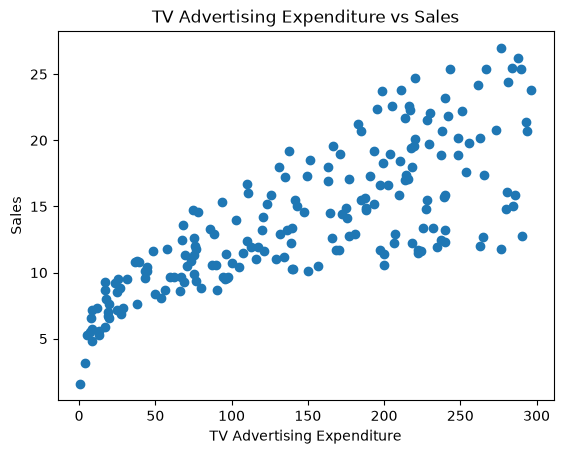

In [10]:
#Create scatter plot
import matplotlib.pyplot as plt

plt.scatter(data["TV Ad Budget ($)"], data["Sales ($)"])

plt.xlabel("TV Advertising Expenditure")
plt.ylabel("Sales")
plt.title("TV Advertising Expenditure vs Sales")

plt.show()

In [11]:
#Develop Simple Linear Regression Model
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = LinearRegression()

model.fit(X_train, y_train)

print("Linear Regression Model Created")

Linear Regression Model Created


In [12]:
#Display Regression Equation
b0 = model.intercept_
b1 = model.coef_[0]

print("Regression Equation:")
print(f"Sales = {b0:.2f} + {b1:.2f} × Advertising")

Regression Equation:
Sales = 7.12 + 0.05 × Advertising


In [13]:
#Predict Sales
advertising_value = 100

predicted_sales = model.predict([[advertising_value]])

print("Advertising Expenditure:", advertising_value)
print("Predicted Sales:", predicted_sales[0])

Advertising Expenditure: 100
Predicted Sales: 11.772611801137288


c:\Users\mvlui\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [ ]:
#Calculate R² Score
from sklearn.metrics import r2_score

y_pred = model.predict(X_test)
r2 = r2_score(y_test, y_pred)
print("R2 Score:", r2)

R2 Score: 0.6766954295627076


In [15]:
#Calculate MSE
from sklearn.metrics import mean_squared_error

mse = mean_squared_error(y_test, y_pred)

print("Mean Squared Error:", mse)

Mean Squared Error: 10.204654118800956


In [16]:
#Compare Actual and Predicted Sales
comparison = pd.DataFrame({
    "Actual Sales": y_test.values,
    "Predicted Sales": y_pred
})

print(comparison)

    Actual Sales  Predicted Sales
0           16.9        14.717944
1           22.4        16.211548
2           21.4        20.748197
3            7.3         7.664036
4           24.7        17.370139
5           12.6        10.614021
6           22.3        17.207285
7            8.4         9.446125
8           11.5        17.467851
9           14.9        15.266995
10           9.5         8.585325
11           8.7         9.734609
12          11.9        18.030861
13           5.3         7.370899
14          10.3        13.610536
15          11.7        15.038999
16           5.5         7.459305
17          16.6        16.313914
18          11.3        10.623327
19          18.9        18.165797
20          19.7        17.798212
21          12.5        10.274354
22          10.9         8.887768
23          22.2        18.793949
24           9.3        10.330190
25           8.1         9.608979
26          21.7        17.053737
27          13.4        13.601230
28          10

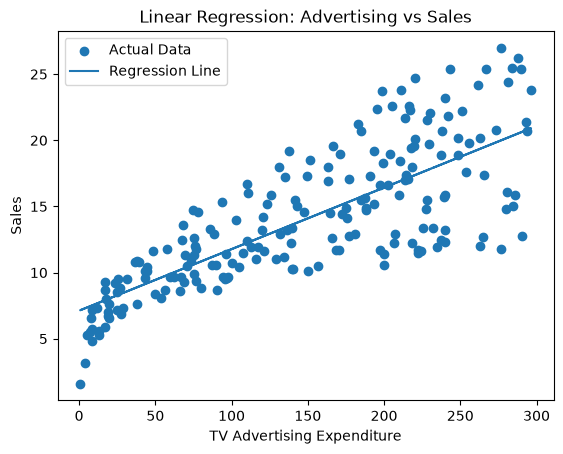

In [17]:
#Plot Regression Line
plt.scatter(X, y, label="Actual Data")

plt.plot(X, model.predict(X), label="Regression Line")

plt.xlabel("TV Advertising Expenditure")
plt.ylabel("Sales")
plt.title("Linear Regression: Advertising vs Sales")

plt.legend()
plt.show()

In [18]:
#Interpret Regression Results
print("Interpretation:")
print(f"For every 1 unit increase in advertising, sales increase by approximately {b1:.2f} units.")
print(f"R2 Score = {r2:.4f}")

Interpretation:
For every 1 unit increase in advertising, sales increase by approximately 0.05 units.
R2 Score = 0.6767


In [19]:
#conclusion 
#There is a positive relationship between TV advertising expenditure and sales.
#  As the advertising expenditure increases, sales generally increase.
# The regression model can be used to predict sales based on advertising expenditure.
